# Evaluation and Visualization of Segmented Linear Regression

---

# Import Libraries

In [2]:
import sys
import os
root = os.path.abspath('..')  
sys.path.append(root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from piecewise_regression import r_squared_calc


from modules import load, plots, analysis, utils

# styles
plt.style.use('seaborn-v0_8-white')

---

## Parameters

In [ ]:
# FILE_NAME: Name of the input CSV file containing raw profile measurements (e.g., depth vs conductivity).
ID_PROFILE_NAME = 'BW9D_YSI_20230823'
# INPUT_DIR: Folder (relative to project root) where input files are located.
INPUT_DIR_JSON = os.path.join(root, 'data', 'results')

INPUT_DIR_PROCESSED = os.path.join(root, 'data', 'rawdy')
# FILE_PATH: Full path to the input file. If you set this explicitly, it takes precedence over INPUT_DIR/FILE_NAME.
FILE_PATH_JSON = os.path.join(INPUT_DIR_JSON, ID_PROFILE_NAME + '_rowdy_bic.json')

FILE_PROCESSED_PATH = os.path.join(INPUT_DIR_PROCESSED, ID_PROFILE_NAME + '_rowdy.csv')

CALCULATE_OPTIMAL_TRIAL = True

TRIAL = '1'

N_BREAKPOINT = 3

# Column names in the input CSV (edit these if your file headers differ)
VP_NAME = 'Vertical Position [m]'           # independent variable (x)
SEC_NAME = 'Corrected sp Cond [uS/cm]'      # dependent variable (y)


---

## Load data

In [16]:
df_json_bic = pd.read_json(FILE_PATH_JSON)
df_json_bic

,trial_1,trial_2
df,"{'bic': {'0': 77052.8251666987, '1': 75746.121...","{'bic': {'0': 77052.8251666987, '1': 75746.121..."
best_n_breakpoint_bic,1,1
min_bic_n_breakpoint,3,3
best_n_breakpoint_rss,2,2


In [32]:
# Prefer FILE_PATH if set; otherwise, compose from INPUT_DIR and FILE_NAME
csv_path = FILE_PROCESSED_PATH if os.path.isabs(FILE_PROCESSED_PATH) or FILE_PROCESSED_PATH else os.path.join(INPUT_DIR_PROCESSED, ID_PROFILE_NAME + '_rowdy_processed.csv')
print(f"Reading data from: {csv_path}")
df_processed = pd.read_csv(csv_path)

# Extract vectors
x_processed = df_processed[VP_NAME].to_numpy()
y_processed = df_processed[SEC_NAME].to_numpy()

df_processed.head()

Reading data from: c:\Users\Arhui\Desktop\proyectos\mar\freshwater_lens\data\rawdy\BW9D_YSI_20230823_rowdy.csv


,Vertical Position [m],Corrected sp Cond [uS/cm]
0,0.000,1024.3
1,0.009,1025.0
2,0.017,1025.3
3,0.025,1025.9
4,0.035,1026.5


---

### Calculate optimal `n_breakpoint`

In [27]:
if CALCULATE_OPTIMAL_TRIAL:
    trial = analysis.select_best_trial(FILE_PATH_JSON)
    trial_select = df_json_bic[trial[0]]
    #N_BREAKPOINT = df.loc['best_n_breakpoint_bic'].mode().iloc[0] # alternative, select 'best_n_breakpoint_rss'
else:
    trial_select = df_json_bic[f'trial_{TRIAL}']

In [29]:
# Elbow plot

x_values = np.array(list(trial_select['df']['n_breakpoints'].values()))
y_values = np.array(list(trial_select['df']['bic'].values()))
secondary_x = np.array(list(trial_select['df']['n_breakpoints'].values()))
secondary_y = np.array(list(trial_select['df']['rss'].values()))

plots.plot_data(
    x_values=x_values,
    y_values=y_values,
    plot_mode='lines+markers',
    x_axis_label="Number Breakpoints",
    y_axis_label="BIC",
    secondary_x=secondary_x,
    secondary_y=secondary_y,
    use_secondary_axis=True,
    y2_axis_label="RSS",
    trace_names=['BIC', 'RSS'],
    title=f"Elbow Plot: <b>{ID_PROFILE_NAME}<b>",
)

---

### Evaluation

In [31]:
# Params
params_ms = utils.get_breakpoint_data(trial_select['df'], N_BREAKPOINT)
params_ms

{'bic': 54633.6739064713,
 'n_breakpoints': 3,
 'estimates': {'const': {'estimate': -53.1765824433,
   'se': 31.1932132994,
   'confidence_interval': [-114.3320147339, 7.9788498472],
   't_stat': -1.7047484635,
   'p_t': 0.0883162841},
  'beta1': {'estimate': 39446.9643677944,
   'se': 205.7318860943,
   'confidence_interval': [39043.6195020602, 39850.3092335286],
   't_stat': 191.7396720395,
   'p_t': '-'},
  'breakpoint1': {'estimate': 14.1538845828,
   'se': 0.0029417568,
   'confidence_interval': [14.1481171614, 14.1596520042],
   't_stat': '-',
   'p_t': '-'},
  'beta2': {'estimate': -32134.1877091326,
   'se': 309.6330880145,
   'confidence_interval': [-32741.2346705103, -31527.1407477549],
   't_stat': -103.7815044742,
   'p_t': '-'},
  'breakpoint2': {'estimate': 15.0889846765,
   'se': 0.0050194511,
   'confidence_interval': [15.0791438595, 15.0988254935],
   't_stat': '-',
   'p_t': '-'},
  'beta3': {'estimate': -7158.5246290039,
   'se': 231.4910198395,
   'confidence_interv

In [33]:
# Model Select
ms = utils.rebuild_model(x_processed,y_processed,params_ms)
ms

In [34]:
# Globals
RSS, TSS, R2, R2_ajus = r_squared_calc.get_r_squared(y_processed, 
                                                    ms.predict(x_processed), 
                                                    len(ms.get_params()))


print("RSS: ", RSS)
print("TSS: ", TSS)
print("R2: ", R2)
print("R2_ajus: ", R2_ajus)

RSS:  2111718380.364707
TSS:  2373431678485.6226
R2:  0.9991102678878407
R2_ajus:  0.9991076889541823


In [35]:
# Per segment
metric_per_segment = analysis.calculate_metrics_per_segment(ms)
metric_per_segment

[{'Segment': 1,
  'R^2': np.float64(0.8278218477003362),
  'RMS%': np.float64(36.59792931232888),
  'RMS% (min-max)': np.float64(11.173299937008018)},
 {'Segment': 2,
  'R^2': np.float64(0.9798830599240747),
  'RMS%': np.float64(6.932783672646126),
  'RMS% (min-max)': np.float64(4.239225000238398)},
 {'Segment': 3,
  'R^2': np.float64(0.9480809714090339),
  'RMS%': np.float64(0.9542653411765264),
  'RMS% (min-max)': np.float64(6.463318158031131)},
 {'Segment': 4,
  'R^2': np.float64(0.9031164119759578),
  'RMS%': np.float64(1.1595458841941237),
  'RMS% (min-max)': np.float64(9.415646449482793)}]

In [36]:
# Breakpoints
breakpoints = analysis.extract_breakpoints(ms)
breakpoints

,Breakpoint X Position,Breakpoint Y Position,Confidence Interval (X)
1,14.153885,5273.789955,"(14.148117161403114, 14.159652004195706)"
2,15.088985,42512.585000,"(15.079143859540277, 15.098825493512223)"
3,16.027549,49729.337019,"(15.992002186337745, 16.06309632737747)"


##

---

### Final results

#### General models

In [40]:
# Visualizamos los datos procesados junto con los modelos obtenidos
df_ms = pd.DataFrame({'n_breakpoints': trial_select['df']['n_breakpoints'], 
                    'estimates': trial_select['df']['estimates']})

plots.interactive_segmented_regression(x=x_processed, 
                                       y=y_processed, 
                                       df=df_ms, 
                                       title=f"{ID_PROFILE_NAME}",
                                       breakpoints=N_BREAKPOINT)

interactive(children=(IntSlider(value=3, description='n_breakpoints', max=10), Output()), _dom_classes=('widge…

#### Models per segment

In [41]:
segments = utils.extract_segments(ms)   
segments

{'segments': [{'segment': 1,
   'data_x': array([0.0000e+00, 9.0000e-03, 1.7000e-02, ..., 1.4131e+01, 1.4146e+01,
          1.4151e+01], shape=(2364,)),
   'data_y': array([1024.3, 1025. , 1025.3, ..., 7200.9, 7213.2, 7229.8], shape=(2364,)),
   'fitted_model': {'slope': np.float64(376.3607443660089),
    'intercept': np.float64(-53.17658244337076),
    'fitted_y': array([ -53.17658244,  -49.78933574,  -46.77844979, ..., 5265.17709619,
           5270.82250736, 5272.70431108], shape=(2364,))}},
  {'segment': 2,
   'data_x': array([14.156, 14.172, 14.176, 14.179, 14.188, 14.192, 14.194, 14.207,
          14.213, 14.214, 14.225, 14.229, 14.233, 14.247, 14.251, 14.255,
          14.264, 14.265, 14.27 , 14.276, 14.283, 14.284, 14.296, 14.301,
          14.305, 14.309, 14.321, 14.326, 14.333, 14.353, 14.357, 14.358,
          14.368, 14.373, 14.376, 14.387, 14.394, 14.396, 14.397, 14.409,
          14.411, 14.427, 14.428, 14.429, 14.438, 14.443, 14.444, 14.452,
          14.455, 14.459, 14.

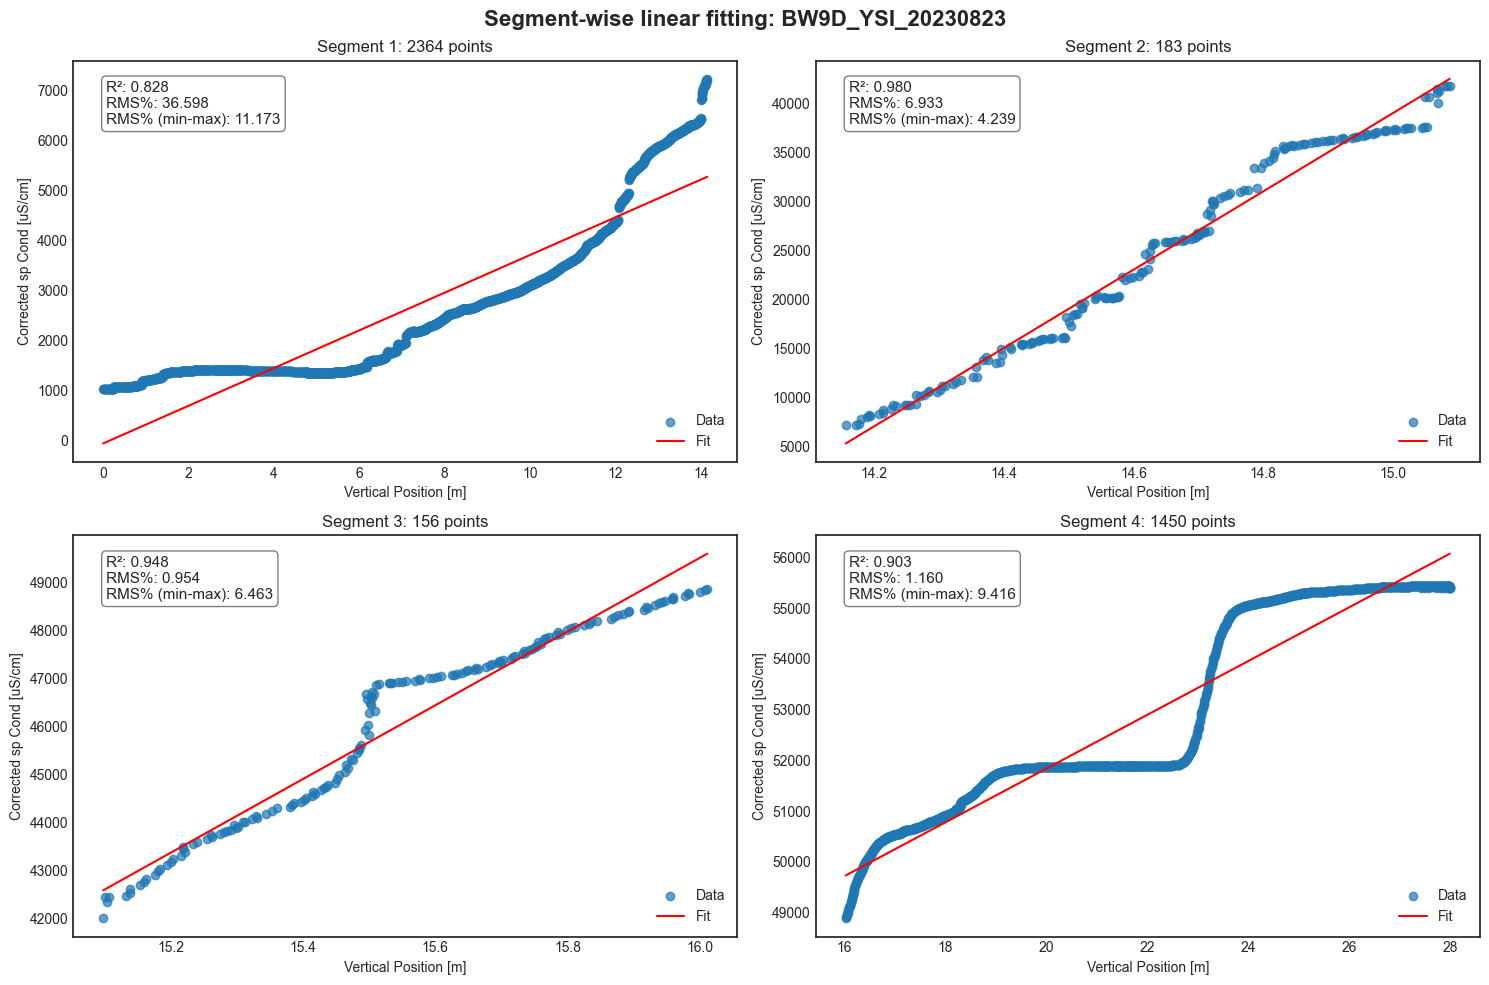

In [43]:
plots.plot_segments(segments, 
                    metric_per_segment, 
                    title=f"Segment-wise linear fitting: {ID_PROFILE_NAME}")

---

## Other analysis

### 1. Density of points in processed data


In [44]:
width = 1 # meters

density = analysis.calculate_density(x_processed, y_processed, bin_width=width)

In [46]:
# Plot data density
plots.plot_histogram(density,
            value_column='x_bin', 
            weight_column='frequency', 
            num_bins=len(density['x_bin']),
            title=f'Data density histogram (bin width = {width} m) | <b>{ID_PROFILE_NAME}<b>',
            x_axis_title='Vertical Position [m]',
            bar_color='lightgreen'
            ) 